In [1]:
%cd ../..

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/cvfm4rehab


# Results to Latex

In [2]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional

import pandas as pd


# ---- helpers ---------------------------------------------------------------

def _safe_float(x: Any) -> Optional[float]:
    """Return float(x) or None if not convertible."""
    try:
        return float(x) if x is not None else None
    except (TypeError, ValueError):
        return None


def _parse_model_args(model_args_str: str) -> Dict[str, str]:
    """
    Parse a 'k=v,k2=v2,...' string into a dict with stripped keys/vals.
    Non 'k=v' chunks are ignored.
    """
    out: Dict[str, str] = {}
    if not model_args_str:
        return out
    for kv in model_args_str.split(","):
        if "=" in kv:
            k, v = kv.split("=", 1)
            out[k.strip()] = v.strip()
    return out


# ---- per-file --------------------------------------------------------------

def extract_eval_row_from_file(file_path: str | Path) -> Optional[Dict[str, Any]]:
    """
    Read one '*_results.json' file and extract a flat row dict.

    Fields produced:
      - file (basename of the JSON file)
      - "edit_score,combine-and-parse"
      - "edit_score_stderr,combine-and-parse"
      - "action_error_rate,combine-and-parse"
      - "action_error_rate_stderr,combine-and-parse"
      - "mae_avg,combine-and-parse"
      - "mae_avg_stderr,combine-and-parse"
      - "prompt" (from configs -> ... -> lmms_eval_specific_kwargs)
      - "use_video_with_segmentations" (same)
      - "total_evaluation_time_seconds" (top level, coerced to float if possible)
      - "max_frames_num" (from parsed config.model_args)
      - "sampling_fps"   (from parsed config.model_args)

    Notes:
      * If the file is unreadable, invalid JSON, or lacks expected blocks, returns None.
      * Automatically picks the (single) task key found under results/configs.

    Parameters
    ----------
    file_path : str | Path

    Returns
    -------
    dict | None
        A single “row” dict, or None if the file cannot be parsed.
    """
    fp = Path(file_path)
    try:
        with fp.open("r") as f:
            data = json.load(f)
    except Exception:
        return None  # unreadable/invalid JSON

    # Extract task blocks (first key under "results" and matching in "configs")
    results_block: Dict[str, Any] = data.get("results", {}) or {}
    task_key: Optional[str] = next(iter(results_block.keys()), None)
    task_obj: Dict[str, Any] = results_block.get(task_key, {}) if task_key else {}

    configs_block: Dict[str, Any] = data.get("configs", {}) or {}
    config_obj: Dict[str, Any] = configs_block.get(task_key, {}) if task_key else {}
    lmms_kwargs: Dict[str, Any] = (config_obj.get("lmms_eval_specific_kwargs") or {}) if isinstance(config_obj, dict) else {}

    total_eval_time = _safe_float(data.get("total_evaluation_time_seconds"))

    model_args_str = ((data.get("config") or {}).get("model_args")) or ""
    parsed_args = _parse_model_args(model_args_str)

    row = {
        "file": fp.name,
        "edit_score,combine-and-parse": task_obj.get("edit_score,combine-and-parse"),
        "edit_score_stderr,combine-and-parse": task_obj.get("edit_score_stderr,combine-and-parse"),
        "action_error_rate,combine-and-parse": task_obj.get("action_error_rate,combine-and-parse"),
        "action_error_rate_stderr,combine-and-parse": task_obj.get("action_error_rate_stderr,combine-and-parse"),
        "mae_avg,combine-and-parse": task_obj.get("mae_avg,combine-and-parse"),
        "mae_avg_stderr,combine-and-parse": task_obj.get("mae_avg_stderr,combine-and-parse"),
        "prompt": lmms_kwargs.get("prompt"),
        "use_video_with_segmentations": lmms_kwargs.get("use_video_with_segmentations"),
        "total_evaluation_time_seconds": total_eval_time,
        "max_frames_num": parsed_args.get("max_frames_num"),
        "sampling_fps": parsed_args.get("sampling_fps"),
    }
    return row


# ---- per-folder (aggregator) ----------------------------------------------

def collect_eval_results(dir_path: str | Path) -> pd.DataFrame:
    """
    Scan a directory for files named '*_results.json' and produce one row per file.

    This mirrors the behavior of the original function, but delegates per-file
    parsing to `extract_eval_row_from_file`.

    Parameters
    ----------
    dir_path : str | Path
        Directory containing the result JSON files.

    Returns
    -------
    pandas.DataFrame
        One row per JSON file with the requested fields.
    """
    dir_path = Path(dir_path)
    rows: List[Dict[str, Any]] = []

    for fp in sorted(dir_path.glob("**/*_results.json")):
        row = extract_eval_row_from_file(fp)
        if row is not None:
            row["rel_path"] = str(fp.relative_to(dir_path))
            row["folder"] = str(fp.parent.relative_to(dir_path))
            rows.append(row)

    df = pd.DataFrame(rows)

    # Optional: enforce a consistent column order
    desired_cols = [
        "file",
        "edit_score,combine-and-parse",
        "edit_score_stderr,combine-and-parse",
        "action_error_rate,combine-and-parse",
        "action_error_rate_stderr,combine-and-parse",
        "mae_avg,combine-and-parse",
        "mae_avg_stderr,combine-and-parse",
        "prompt",
        "use_video_with_segmentations",
        "total_evaluation_time_seconds",
        "max_frames_num",
        "sampling_fps",
    ]
    # Keep any extra columns at the end (if ever added upstream)
    ordered_cols = [c for c in desired_cols if c in df.columns] + [c for c in df.columns if c not in desired_cols]
    return df.reindex(columns=ordered_cols)


In [3]:
import pandas as pd
import re
from typing import Optional

PROMPT_MAP = {
    "single_prediction": "SP",
    "single_motion_and_contact": "SMC",
    "ideal": "Ideal"
}

def _pm(val: Optional[float], err: Optional[float], fmt: str = "{:.2f}") -> str:
    """Return 'val ± err' (both formatted) or '–' if val is missing."""
    if pd.isna(val):
        return "–"
    s = fmt.format(val)
    if pd.isna(err) or (err == 0):
        return s
    return f"{s} ± {fmt.format(err)}"

def _fmt_runtime(seconds: Optional[float]) -> str:
    """Format seconds as H:MM:SS (or '–' if missing)."""
    if pd.isna(seconds):
        return "–"
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(round(seconds % 60))
    return f"{h}:{m:02d}:{s:02d}"

def make_results_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a display DataFrame with columns:
    FPS | Frames | Prompt | ES | AER | MAE | Run time
    (ES/AER/MAE shown as 'mean ± stderr')
    """
    out = pd.DataFrame({
        "_file": df.get("file"),
        "FPS": pd.to_numeric(df.get("sampling_fps"), errors="coerce"),
        "Frames": pd.to_numeric(df.get("max_frames_num"), errors="coerce"),
        "Prompt": df.get("prompt").map(PROMPT_MAP).fillna(df.get("prompt")),
        "ES": [
            _pm(v, e) for v, e in zip(
                df.get("edit_score,combine-and-parse"),
                df.get("edit_score_stderr,combine-and-parse"),
            )
        ],
        "AER": [
            _pm(v, e) for v, e in zip(
                df.get("action_error_rate,combine-and-parse"),
                df.get("action_error_rate_stderr,combine-and-parse"),
            )
        ],
        "MAE": [
            _pm(v, e) for v, e in zip(
                df.get("mae_avg,combine-and-parse"),
                df.get("mae_avg_stderr,combine-and-parse"),
            )
        ],
        "Run time": df.get("total_evaluation_time_seconds").map(_fmt_runtime),
    })

    columns_so_far = ["file", "sampling_fps", "max_frames_num", "prompt",
                      "edit_score,combine-and-parse", "edit_score_stderr,combine-and-parse",
                      "action_error_rate,combine-and-parse", "action_error_rate_stderr,combine-and-parse",
                      "mae_avg,combine-and-parse", "mae_avg_stderr,combine-and-parse",
                      "total_evaluation_time_seconds"
    ]
    columns_remaining = [c for c in df.columns if c not in columns_so_far]
    for c in columns_remaining:
        out[c] = df[c]

    # Sort by window size
    out["Inverse Window Size"] = (out["FPS"] / out["Frames"]).map(lambda x: int(round(x)))

    out = out.sort_values(["Inverse Window Size"], kind="stable", na_position="last").reset_index(drop=True)
    # Rename
    out.rename(columns={"Inverse Window Size": "$1/d$ (rounded)", "FPS": "$f$", "Frames": "$n$"}, inplace=True)
    return out


def _wrap_best(cell: str, rank: int) -> str:
    """
    rank=0 -> best (green), rank=1 -> second-best (blue), otherwise unchanged.
    """
    if rank == 0:
        return r"\cellcolor{green!20}\textbf{" + cell + "}"
    if rank == 1:
        return r"\cellcolor{blue!20}\textbf{" + cell + "}"
    return cell


def apply_best_second_styling(table_df: pd.DataFrame) -> pd.DataFrame:
    """
    Color + bold the best (green) and second-best (blue) for ES/AER/MAE.
    Works directly from table_df where metrics look like '40.27 ± 1.69'.
    Requires `_wrap_best` defined elsewhere.
    """
    styled = table_df.copy()

    def _extract_val(s: str) -> float | None:
        """Extract the numeric value before '±' (or full string if plain number)."""
        if pd.isna(s):
            return None
        m = re.match(r"^\s*([+-]?\d+(?:\.\d+)?)", str(s))
        return float(m.group(1)) if m else None

    metric_specs = [
        ("ES",  True),   # higher is better
        ("AER", False),  # lower is better
        ("MAE", False),  # lower is better
    ]

    for colname, higher_is_better in metric_specs:
        vals = table_df[colname].map(_extract_val)

        # drop NAs but preserve index alignment
        valid = vals.dropna()
        if valid.empty:
            continue

        # sort by metric, respecting higher/lower is better
        sorted_idx = valid.sort_values(ascending=not higher_is_better).index.tolist()

        best_idx = sorted_idx[0]
        second_idx = sorted_idx[1] if len(sorted_idx) > 1 else None

        styled.loc[best_idx, colname] = _wrap_best(styled.loc[best_idx, colname], rank=0)
        if second_idx is not None:
            styled.loc[second_idx, colname] = _wrap_best(styled.loc[second_idx, colname], rank=1)

    return styled



def results_table_to_latex(table_df: pd.DataFrame) -> str:
    """
    Convert to LaTeX with arrows in metric headers.
    Requires: \\usepackage{booktabs} and \\usepackage[table]{xcolor} in your preamble.
    """
    # rename headers with arrows
    renamed = table_df.rename(columns={
        "ES":  "ES $\\uparrow$",
        "AER": "AER $\\downarrow$",
        "MAE": "MAE $\\downarrow$",
    }).drop(columns=["_file"], errors="ignore")

    col_format = "rrlccc r".replace(" ", "")  # 'rrlcccr'
    return renamed.to_latex(index=False, escape=False, column_format=col_format)



In [4]:
path_1 = "./logs/strokerehab_primitives_1/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
idf = collect_eval_results(path_1)
path_2 = "./logs/strokerehab_primitives_2/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
spdf = collect_eval_results(path_2)
path_3 = "./logs/strokerehab_primitives_3/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
smcdf = collect_eval_results(path_3)

In [6]:
df = pd.concat([idf, spdf], ignore_index=True)
df['max_frames_num'] = df['max_frames_num'].astype(int)
df['sampling_fps'] = df['sampling_fps'].astype(int)

ideal_fn_filter = (
    ((df['sampling_fps'] == 1) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 2)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 2)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 15) & (df['max_frames_num'] == 15)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 15)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 15))
)
df = df[ideal_fn_filter]
tbl = make_results_table(df)
tbl = tbl[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "MAE", "Run time"]].copy()
tbl.drop(columns=["Run time"], inplace=True)
tbl_styled = apply_best_second_styling(tbl)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
$1/d$ (rounded) & $f$ & $n$ & Prompt & ES $\uparrow$ & AER $\downarrow$ & MAE $\downarrow$ \\
\midrule
0 & 4 & 8 & Ideal & 25.91 ± 1.49 & 2.38 ± 0.24 & 16.52 ± 1.72 \\
0 & 2 & 8 & Ideal & \cellcolor{green!20}\textbf{37.21 ± 1.45} & 1.03 ± 0.11 & 7.74 ± 0.83 \\
0 & 4 & 15 & Ideal & \cellcolor{blue!20}\textbf{35.45 ± 1.67} & 1.20 ± 0.14 & 9.15 ± 0.99 \\
0 & 4 & 8 & SP & 16.71 ± 1.54 & 0.83 ± 0.02 & 6.09 ± 0.56 \\
1 & 1 & 1 & Ideal & 20.54 ± 1.31 & 3.94 ± 0.35 & 25.89 ± 2.74 \\
1 & 2 & 2 & Ideal & 19.29 ± 1.20 & 4.24 ± 0.39 & 27.72 ± 2.83 \\
1 & 8 & 8 & Ideal & 17.09 ± 1.06 & 4.71 ± 0.45 & 31.16 ± 3.28 \\
1 & 8 & 15 & Ideal & 25.47 ± 1.43 & 2.42 ± 0.26 & 17.01 ± 1.84 \\
1 & 1 & 1 & SP & 25.24 ± 1.72 & 0.76 ± 0.02 & \cellcolor{green!20}\textbf{5.61 ± 0.53} \\
1 & 2 & 2 & SP & 23.82 ± 1.87 & \cellcolor{blue!20}\textbf{0.76 ± 0.02} & 5.72 ± 0.54 \\
1 & 8 & 8 & SP & 23.54 ± 1.92 & 0.76 ± 0.02 & 5.67 ± 0.54 \\
1 & 15 & 15 & SP & 24.56 ± 2.09 & 0.76 ± 0.02 & \c

In [78]:
tbl_spdf = make_results_table(spdf)
tbl_spdf = tbl_spdf[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "MAE", "Run time"]].copy()
tbl_spdf.drop(columns=['Prompt'], inplace=True)
tbl_styled = apply_best_second_styling(tbl_spdf)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
$1/d$ (rounded) & $f$ & $n$ & ES $\uparrow$ & AER $\downarrow$ & MAE $\downarrow$ & Run time \\
\midrule
0 & 1 & 2 & 17.41 ± 1.30 & 0.83 ± 0.01 & 5.95 ± 0.55 & 0:08:54 \\
0 & 2 & 4 & 17.35 ± 1.56 & 0.83 ± 0.02 & 6.02 ± 0.56 & 0:17:52 \\
0 & 4 & 8 & 16.71 ± 1.54 & 0.83 ± 0.02 & 6.09 ± 0.56 & 0:41:51 \\
1 & 1 & 1 & 25.24 ± 1.72 & 0.76 ± 0.02 & 5.61 ± 0.53 & 0:16:26 \\
1 & 2 & 2 & 23.82 ± 1.87 & 0.76 ± 0.02 & 5.72 ± 0.54 & 0:17:02 \\
1 & 4 & 4 & 22.71 ± 1.86 & 0.77 ± 0.02 & 5.65 ± 0.53 & 0:35:10 \\
1 & 8 & 8 & 23.54 ± 1.92 & 0.76 ± 0.02 & 5.67 ± 0.54 & 1:18:09 \\
1 & 15 & 15 & 24.56 ± 2.09 & 0.76 ± 0.02 & 5.64 ± 0.52 & 3:47:42 \\
1 & 30 & 30 & 25.94 ± 2.23 & 0.74 ± 0.02 & \cellcolor{green!20}\textbf{5.56 ± 0.52} & 11:17:09 \\
2 & 2 & 1 & 30.36 ± 1.86 & 0.76 ± 0.05 & 5.88 ± 0.57 & 0:32:18 \\
2 & 4 & 2 & 29.97 ± 1.84 & 0.74 ± 0.03 & 5.78 ± 0.53 & 0:33:15 \\
2 & 8 & 4 & 26.76 ± 1.98 & 0.75 ± 0.03 & 5.67 ± 0.52 & 1:05:11 \\
2 & 15 & 8 & 28.35 ± 2.13 & \cellco

In [80]:
df = pd.concat([spdf, smcdf], ignore_index=True)
tbl = make_results_table(df)
tbl = tbl[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "MAE", "Run time"]].copy()
remove_filter = (
    tbl["$1/d$ (rounded)"].isin([0, 1])
)
tbl = tbl[~remove_filter]

tbl_styled = apply_best_second_styling(tbl)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
$1/d$ (rounded) & $f$ & $n$ & Prompt & ES $\uparrow$ & AER $\downarrow$ & MAE $\downarrow$ & Run time \\
\midrule
2 & 2 & 1 & SP & 30.36 ± 1.86 & 0.76 ± 0.05 & 5.88 ± 0.57 & 0:32:18 \\
2 & 4 & 2 & SP & 29.97 ± 1.84 & 0.74 ± 0.03 & 5.78 ± 0.53 & 0:33:15 \\
2 & 8 & 4 & SP & 26.76 ± 1.98 & 0.75 ± 0.03 & 5.67 ± 0.52 & 1:05:11 \\
2 & 15 & 8 & SP & 28.35 ± 2.13 & 0.74 ± 0.02 & 5.60 ± 0.52 & 2:35:08 \\
2 & 30 & 15 & SP & 30.54 ± 2.14 & 0.74 ± 0.03 & 5.74 ± 0.53 & 7:34:44 \\
2 & 2 & 1 & SMC & 30.68 ± 2.49 & 0.75 ± 0.04 & 5.47 ± 0.54 & 0:40:23 \\
2 & 4 & 2 & SMC & 32.43 ± 2.44 & 0.72 ± 0.03 & 5.66 ± 0.66 & 0:43:54 \\
2 & 8 & 4 & SMC & 34.09 ± 2.49 & 0.69 ± 0.03 & 5.32 ± 0.56 & 1:17:52 \\
2 & 15 & 8 & SMC & 36.32 ± 2.41 & \cellcolor{blue!20}\textbf{0.68 ± 0.04} & \cellcolor{blue!20}\textbf{5.04 ± 0.49} & 2:56:10 \\
2 & 30 & 15 & SMC & \cellcolor{blue!20}\textbf{37.63 ± 2.31} & \cellcolor{green!20}\textbf{0.66 ± 0.03} & \cellcolor{green!20}\textbf{4.81 ± 0.44} & 

## LLMs Ablation

In [25]:
import datetime as dt
import re

def extract_timestamp_from_filename(fname: str) -> dt.datetime | None:
    m = re.match(r"(\d{8}_\d{6})", fname)
    if not m:
        return None
    try:
        return dt.datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
    except ValueError:
        return None


In [38]:
all_results = collect_eval_results("./logs/strokerehab_primitives_3/")
all_results['date'] = all_results['file'].map(extract_timestamp_from_filename)
all_results['sampling_fps'] = all_results['sampling_fps'].astype(int)
all_results['max_frames_num'] = all_results['max_frames_num'].astype(int)
all_results.sort_values(by=['date', 'folder'], inplace=True)
all_results = all_results[(all_results['sampling_fps'] == 15) & (all_results['max_frames_num'] == 8)]
latest_results = all_results.groupby(['folder']).first()
tbl = make_results_table(latest_results)

tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_3.jsonl"))
tbl['model'] = tbl['rel_path'].apply(lambda s: s.split('/')[0])
def extract_model_and_size(s: str) -> tuple[str, float]:
    try:
        size_start_idx = -1
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    except ValueError:
        size_start_idx = -2
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    model_family = '_'.join(s.split('_')[0:size_start_idx])
    return model_family, size
tbl[['model_family', 'model_size']] = tbl['model'].apply(
    lambda s: pd.Series(extract_model_and_size(s))
)
tbl.sort_values(by=['model_family', 'model_size'], inplace=True)
tbl.drop(columns=['model_family', 'model_size'], inplace=True)
tbl['model'] = tbl['model'].apply(lambda s: s.replace('_', r'\_'))
tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_3.jsonl"))


In [39]:
tbl_ = tbl[["_file", "model", "ES", "AER", "MAE", "Run time"]].copy()
tbl_styled = apply_best_second_styling(tbl_)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
model & ES $\uparrow$ & AER $\downarrow$ & MAE $\downarrow$ & Run time \\
\midrule
internvl3\_78b & 43.56 ± 1.59 & 0.74 ± 0.06 & 5.52 ± 0.51 & 9:47:52 \\
internvl3p5\_1b & 40.27 ± 1.69 & 0.81 ± 0.08 & 5.87 ± 0.57 & 0:54:50 \\
internvl3p5\_2b & 33.95 ± 2.35 & 0.73 ± 0.04 & 5.25 ± 0.56 & 1:22:15 \\
internvl3p5\_4b & 42.67 ± 1.38 & 0.77 ± 0.08 & 5.75 ± 0.52 & 1:57:47 \\
internvl3p5\_8b & 9.12 ± 1.21 & 0.91 ± 0.01 & 6.57 ± 0.61 & 2:04:08 \\
internvl3p5\_14b & \cellcolor{green!20}\textbf{46.29 ± 1.53} & 0.68 ± 0.05 & 5.13 ± 0.50 & 3:33:41 \\
internvl3p5\_30b\_a3b & 26.34 ± 2.16 & 0.77 ± 0.03 & 6.08 ± 0.65 & 10:27:39 \\
internvl3p5\_38b & 36.87 ± 2.07 & 0.76 ± 0.05 & 5.51 ± 0.50 & 6:20:56 \\
llava\_next\_video\_7b & 44.57 ± 1.84 & \cellcolor{green!20}\textbf{0.65 ± 0.05} & \cellcolor{blue!20}\textbf{4.74 ± 0.55} & 1:08:14 \\
llava\_next\_video\_72b & 25.87 ± 2.29 & 0.79 ± 0.03 & 6.90 ± 0.69 & 3:01:09 \\
llava\_ov\_0p5b & 20.42 ± 1.80 & 0.82 ± 0.02 & 6.41 ± 0

# Further Analysis
RUN THE SECTION ABOVE.

In [ ]:
from __future__ import annotations

import json
import gzip
from pathlib import Path
from typing import Iterable, Dict, Any, List

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import math
import html
import io
from typing import List, Dict, Tuple, Optional, Union, Literal

import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont


def _iter_jsonl(path: Path) -> Iterable[Dict[str, Any]]:
    """
    Stream a .jsonl or .jsonl.gz file, yielding parsed JSON objects line by line.
    Skips blank lines; raises on unrecoverable JSON errors.
    """
    opener = gzip.open if path.suffix == ".gz" or path.suffixes[-2:] == [".jsonl", ".gz"] else open
    mode = "rt"  # text mode
    with opener(path, mode, encoding="utf-8") as f:
        for ln, line in enumerate(f, start=1):
            s = line.strip()
            if not s:
                continue
            try:
                yield json.loads(s)
            except json.JSONDecodeError as e:
                raise ValueError(f"JSON decode error in {path} at line {ln}: {e}") from e


def explode_samples_from_jsonl_paths(
    latest_results_table: pd.DataFrame,
    path_col: str = "samples_path",
    log_dir: str | Path = "./logs/strokerehab_primitives_3/",
) -> pd.DataFrame:
    """
    For each JSONL pointed to by `latest_results_table[path_col]`, read every example (one per line)
    and extract: `id`, `target`, and `filtered_resps`.

    Returns a DataFrame that contains all columns from `latest_results_table`
    plus the exploded per-sample fields: [id, target, filtered_resps, edit_score, action_error_rate, mae_avg].

    Notes
    -----
    - `id` is taken from item['doc']['id'] if present, otherwise item['id'].
    - `filtered_resps` is returned as-is (often a string or a list of strings).
    - Supports both .jsonl and .jsonl.gz files.
    """
    if path_col not in latest_results_table.columns:
        raise KeyError(f"`{path_col}` column not found in latest_results_table.")

    rows: List[Dict[str, Any]] = []

    for _, row in latest_results_table.iterrows():
        p = row[path_col]
        if p is None or (isinstance(p, float) and pd.isna(p)):
            continue
        path = Path(log_dir) / p
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

        for item in _iter_jsonl(path):
            doc = item.get("doc", {})
            ex_id = doc.get("id", item.get("id"))

            target = item.get("target")
            filtered_resps = item.get("filtered_resps")
            if isinstance(filtered_resps, list) and len(filtered_resps) == 1:
                filtered_resps = filtered_resps[0]

            rows.append(
                {
                    **row.to_dict(),  # keep all original columns
                    "samples_path": str(path),
                    "id": ex_id,
                    "target": target,
                    "filtered_resps": filtered_resps,
                    "edit_score": item.get("edit_score"),
                    "action_error_rate": item.get("action_error_rate"),
                    "mae_avg": item.get("mae_avg"),
                }
            )

    return pd.DataFrame(rows)




def _parse_segments(seq: str):
    """
    Parse strings like 'idle@0.000;reach@0.917;transport@1.550;...' into
    list of dicts with {'action': str, 't': float}.
    """
    parts = seq.split(";")
    segs = []
    for p in parts:
        if not p.strip():
            continue
        try:
            action, t = p.split("@")
            segs.append({"action": action.strip(), "t": float(t)})
        except ValueError:
            continue
    return segs


def _segments_to_intervals(segs):
    """
    Given [{'action': a, 't': t}, ...] sorted by t, produce intervals
    [{'action': a, 't0': t0, 't1': t1}, ...]
    """
    intervals = []
    for i, s in enumerate(segs):
        t0 = s["t"]
        t1 = segs[i + 1]["t"] if i + 1 < len(segs) else t0
        intervals.append({"action": s["action"], "t0": t0, "t1": t1})
    return intervals


def _to_intervals_up_to_duration(seq: str, duration: float):
    segs = _parse_segments(seq)
    if not segs:
        return []
    ivals = []
    for i, s in enumerate(segs):
        t0 = s["t"]
        t1 = segs[i+1]["t"] if i+1 < len(segs) else duration
        # clip & keep only positive spans
        t0c, t1c = max(0.0, min(t0, duration)), max(0.0, min(t1, duration))
        if t1c > t0c:
            ivals.append({"action": s["action"], "t0": t0c, "t1": t1c})
    return ivals

def row_accuracy(row) -> float:
    tgt_segs = _parse_segments(row["target"])
    if not tgt_segs:
        return np.nan
    duration = tgt_segs[-1]["t"]  # “The last time of the target is the video's duration.”

    tgt = _to_intervals_up_to_duration(row["target"], duration)
    pred = _to_intervals_up_to_duration(row["filtered_resps"], duration)
    if not pred or not tgt or duration <= 0:
        return 0.0

    i = j = 0
    match_time = 0.0
    while i < len(tgt) and j < len(pred):
        a, b = tgt[i], pred[j]
        start = max(a["t0"], b["t0"])
        end   = min(a["t1"], b["t1"])
        if end > start and a["action"] == b["action"]:
            match_time += (end - start)
        # advance whichever interval ends first (both if tie)
        if a["t1"] <= b["t1"]:
            i += 1
        if b["t1"] <= a["t1"]:
            j += 1

    return match_time / duration


# ----------------------------
# Shared helpers
# ----------------------------
_DEFAULT_PALETTE: List[Tuple[int, int, int]] = [
    (230, 25, 75),   # red
    (60, 180, 75),   # green
    (0, 130, 200),   # blue
    (245, 130, 48),  # orange
    (145, 30, 180),  # purple
    (70, 240, 240),  # cyan
    (240, 50, 230),  # magenta
    (210, 245, 60),  # lime
    (250, 190, 190), # pink
    (0, 128, 128),   # teal
    (170, 110, 40),  # brown
    (255, 225, 25),  # yellow
]

def _rgb_hex(rgb: Tuple[int, int, int]) -> str:
    r, g, b = rgb
    return f"#{r:02x}{g:02x}{b:02x}"

def _infer_actions_in_order(label_segments: List[Dict]) -> List[str]:
    seen, order = set(), []
    for s in label_segments:
        a = s["action"]
        if a not in seen:
            seen.add(a)
            order.append(a)
    return order

def _ensure_color_map(actions_in_order: List[str],
                      color_map: Optional[Dict[str, Tuple[int, int, int]]]) -> Dict[str, Tuple[int, int, int]]:
    if color_map is None:
        return {a: _DEFAULT_PALETTE[i % len(_DEFAULT_PALETTE)] for i, a in enumerate(actions_in_order)}
    # validate provided map
    for a in actions_in_order:
        if a not in color_map:
            raise KeyError(f"'{a}' missing from color_map")
        r, g, b = color_map[a]
        for c in (r, g, b):
            if not (isinstance(c, int) and 0 <= c <= 255):
                raise ValueError(f"Invalid RGB value {color_map[a]} for '{a}'")
    return color_map

def plot_bars_for_df(df, color_map=None):
    """
    Draw one plot per ID:
      - Top row: target (ground truth, assumed same across df)
      - Subsequent rows: filtered_resps (one per model)
    """
    if len(df) == 0:
        return
    
    assert df['id'].nunique() == 1, f"Expected 1 id, got: {df['id'].unique()}"

    id_val = df.iloc[0]['id']
    target_segs = _parse_segments(df.iloc[0]["target"])
    target_ints = _segments_to_intervals(target_segs)

    preds = []
    all_ints = target_ints.copy()
    for _, row in df.iterrows():
        pred_segs = _parse_segments(row["filtered_resps"])
        pred_ints = _segments_to_intervals(pred_segs)
        preds.append((row['model'], pred_ints))
        all_ints.extend(pred_ints)

    actions = _infer_actions_in_order(all_ints)
    cmap = _ensure_color_map(actions, color_map)

    nrows = 1 + len(preds)
    bar_height = 0.9  # fill almost all vertical slot

    fig, ax = plt.subplots(figsize=(12, 0.4 * nrows), constrained_layout=True)

    # Plot target
    for iv in target_ints:
        ax.barh(
            y=0, left=iv["t0"], width=iv["t1"] - iv["t0"],
            height=bar_height, color=_rgb_hex(cmap[iv["action"]]), edgecolor="black"
        )

    # Plot preds
    for i, (model, pred_ints) in enumerate(preds, start=1):
        for iv in pred_ints:
            ax.barh(
                y=i, left=iv["t0"], width=iv["t1"] - iv["t0"],
                height=bar_height, color=_rgb_hex(cmap[iv["action"]]), edgecolor="black"
            )

    ax.set_yticks(range(nrows))
    labels = ["target"] + [m.replace('\\', '') for m, _ in preds]
    edit_scores = [""] + [f"(ES={row['edit_score']:.2f})" for _, row in df.iterrows()]
    action_error_rates = [""] + [f"(AER={row['action_error_rate']:.2f})" for _, row in df.iterrows()]
    ax.set_yticklabels([f"{l} {es} {aer}" for l, es, aer in zip(labels, edit_scores, action_error_rates)])
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{id_val}")

    handles = [mpatches.Patch(color=_rgb_hex(cmap[a]), label=a) for a in actions]
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.01, 1),   # push just outside right edge
        loc="upper left",
        fontsize=8,
        frameon=False
    )
    # fig.subplots_adjust(right=0.8)

    # Key trick: eliminate white space between bars
    ax.set_ylim(-0.5, nrows - 0.5)
    ax.margins(y=0)

    return fig

In [48]:
df = explode_samples_from_jsonl_paths(tbl, path_col='samples_path')
df.drop(columns=['_file', '$f$', '$n$', 'Prompt', 'ES', 'AER', 'MAE', 'Run time',
       'use_video_with_segmentations', 'rel_path', 'date', '$1/d$ (rounded)',
       'samples_path'], inplace=True)
# df.set_index(['model', 'id'], inplace=True)

### Question
- Why are the edit score and action error rates so erratic? Let's look into "accuracy," the amount of time in which the prediction and ground truths overlap. **Finding**: accuracy also shows a similar pattern, at least in the qwen and internvl3 family. There is no clear trend in performance gains as the models get larger.
- Something that tanks accuracy and edit score is "failures." Only predicting idles, generally with an edit score below 5.

In [57]:
df["accuracy"] = df.apply(row_accuracy, axis=1)
df.groupby('model', sort=False)[['edit_score', 'action_error_rate', 'mae_avg', 'accuracy']].mean().reset_index()

,model,edit_score,action_error_rate,mae_avg,accuracy
0,internvl3\_78b,43.562262,0.744089,5.524,0.315726
1,internvl3p5\_1b,40.267380,0.809213,5.872,0.278832
2,internvl3p5\_2b,33.952964,0.729191,5.248,0.336753
3,internvl3p5\_4b,42.672282,0.766110,5.748,0.290927
4,internvl3p5\_8b,9.115674,0.908843,6.572,0.265946
5,internvl3p5\_14b,46.291957,0.683746,5.132,0.326923
6,internvl3p5\_30b\_a3b,26.341018,0.774346,6.084,0.270708
7,internvl3p5\_38b,36.872726,0.758271,5.508,0.290760
8,llava\_next\_video\_7b,44.571443,0.654362,4.740,0.337694
9,llava\_next\_video\_72b,25.867788,0.790312,6.896,0.263754


In [59]:
df['failure'] = df['edit_score'] < 5.0

In [93]:
# How many failures does each model have?

failure = df.groupby('model').agg(
    failure=('failure', 'sum'),
    es=('edit_score', 'mean'),
    aer=('action_error_rate', 'mean'),
    mae=('mae_avg', 'mean'),
    acc=('accuracy', 'mean'),
).reset_index()

In [103]:
failure[failure['model'].str.contains('qwen')]

,model,failure,es,aer,mae,acc
16,qwen2\_5\_vl\_32b,0,44.728720,0.681309,4.276,0.401606
17,qwen2\_5\_vl\_72b,4,39.846332,0.648332,4.764,0.391305
18,qwen2\_5\_vl\_7b,2,36.322541,0.684791,5.040,0.343534


In [115]:
# If we take out the samples qwen_72b failed on, how would the comparison between 32b and 72b change?
# - The metrics are now comparable.
# Which example did qwen 72b "fail" on, and why?
failed_ids = set(df[(df['model'] == 'qwen2\_5\_vl\_72b') & (df['failure'])]['id'])
print(f"Qwen72b failed on {len(failed_ids)} examples: {failed_ids}")
model_filter = ['qwen2\_5\_vl\_32b', 'qwen2\_5\_vl\_72b']
df_filt = df[df['model'].isin(model_filter) & (~df['id'].isin(failed_ids))]
df_filt.groupby('model').agg(
    es=('edit_score', 'mean'),
    aer=('action_error_rate', 'mean'),
    mae=('mae_avg', 'mean'),
    acc=('accuracy', 'mean'),
).reset_index()

Qwen72b failed on 4 examples: {'S00026_deodrant5_2', 'S00042_shelf left side2_1', 'S00047_shelf right side3_2', 'S00026_shelf left side5_1'}


,model,es,aer,mae,acc
0,qwen2\_5\_vl\_32b,43.568135,0.700329,4.304348,0.404483
1,qwen2\_5\_vl\_72b,43.074145,0.620123,4.465217,0.409901


In [111]:
set(df[(df['model'] == 'qwen2\_5\_vl\_72b') & (df['failure'])]['id'])

{'S00026_deodrant5_2',
 'S00026_shelf left side5_1',
 'S00042_shelf left side2_1',
 'S00047_shelf right side3_2'}

In [160]:
from vic_pipe.visualize import visualize

# {'S00026_deodrant5_2',
#  'S00026_shelf left side5_1',
#  'S00042_shelf left side2_1',
#  'S00047_shelf right side3_2'}

models = ['qwen2\_5\_vl\_32b', 'qwen2\_5\_vl\_72b']
ids_ = ['S00026_shelf left side5_1', 'S00042_shelf left side2_1', 'S00047_shelf right side3_2']
patients = ['S00026', 'S00042', 'S00047']

# model = "qwen2\_5\_vl\_72b"
# id_ = "S00026_shelf left side5_1"
# patient = "S00026"

for model in models:

    for id_, patient in zip(ids_, patients):

        ex = df[(df['model'] == model) & (df['id'] == id_)]
        out_path = f"./{id_}_{model}.mp4".replace('\\', '')
        path_v = f"/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/{patient}/{id_}.avi"
        def get_actions_times(col):
            segs = _parse_segments(ex.iloc[0][col])
            actions = [s['action'] for s in segs]
            times = [s['t'] for s in segs]
            return actions, times
        pred_labels, pred_times = get_actions_times("filtered_resps")
        gt_labels, gt_times = get_actions_times("target")
        try:
            visualize(
                path_v,
                pred_labels,
                pred_times,
                gt_labels,
                gt_times,
                out_path=out_path,
            )
        except Exception as e:
            visualize(
                path_v.replace('.avi', '.mkv'),
                pred_labels,
                pred_times,
                gt_labels,
                gt_times,
                out_path=out_path,
            )

In [108]:
failed_ids

set()

In [ ]:
# spearman
from scipy.stats import spearmanr
# The performance in 
# This shows that the performance difference in accuracy / edit score between models is largely driven by the number of failures.
spearmanr(failure['failure'], failure['es'])

SignificanceResult(statistic=-0.9467546424599452, pvalue=8.590665942117683e-10)

In [96]:
action2index = {
    'idle': 0,
    'reach': 1,
    'transport': 2,
    'reposition': 3,
    'stabilize': 4,
}
prims = list(action2index.keys())
prims_cols_uncombined = [f'num_uncombined_{p}' for p in prims]
prims_cols_combined = [f'num_{p}' for p in prims]

def extract_prims(s: str) -> pd.Series:
    segs = _parse_segments(s)
    actions = [seg['action'] for seg in segs if seg['action'] in action2index]

    num_actions = [0 for _ in range(5)]
    for a in actions:
        num_actions[action2index[a]] += 1
    return pd.Series(num_actions, index=prims_cols_uncombined)

In [97]:
failure.sort_values(by='failure', ascending=False).head()

,model,failure,es,aer,mae,acc
13,longva\_7b,36,4.602973,0.953970,6.872,0.263681
7,internvl3p5\_8b,22,9.115674,0.908843,6.572,0.265946
14,nvila\_15b,10,23.487056,0.801877,6.600,0.278016
10,llava\_ov\_0p5b,7,20.420296,0.821045,6.412,0.272912
8,llava\_next\_video\_72b,7,25.867788,0.790312,6.896,0.263754


In [98]:
def num_prims(s: str) -> int:
    return len(set([seg['action'] for seg in _parse_segments(s)]))

df[df['model'] == 'longva\_7b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict()  # longva is an idle bot

{'idle': 4488, 'reach': 0, 'transport': 0, 'reposition': 4, 'stabilize': 0}

In [99]:
failure[failure['model'].str.contains('internvl')]

,model,failure,es,aer,mae,acc
0,internvl3\_78b,0,43.562262,0.744089,5.524,0.315726
1,internvl3p5\_14b,0,46.291957,0.683746,5.132,0.326923
2,internvl3p5\_1b,0,40.267380,0.809213,5.872,0.278832
3,internvl3p5\_2b,5,33.952964,0.729191,5.248,0.336753
4,internvl3p5\_30b\_a3b,5,26.341018,0.774346,6.084,0.270708
5,internvl3p5\_38b,3,36.872726,0.758271,5.508,0.290760
6,internvl3p5\_4b,0,42.672282,0.766110,5.748,0.290927
7,internvl3p5\_8b,22,9.115674,0.908843,6.572,0.265946


In [92]:
print("G", df[df['model'] == 'internvl3p5\_1b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict())
print("B", df[df['model'] == 'internvl3p5\_2b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict())
print("G", df[df['model'] == 'internvl3p5\_4b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict())
print("B", df[df['model'] == 'internvl3p5\_8b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict())
print("O", df[df['model'] == 'internvl3p5\_38b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict())
print("G", df[df['model'] == 'internvl3\_78b']['filtered_resps'].apply(extract_prims).sum().rename(index=lambda x: x.split('_')[-1]).to_dict())

G {'idle': 1205, 'reach': 170, 'transport': 1178, 'reposition': 28, 'stabilize': 1911}
B {'idle': 458, 'reach': 182, 'transport': 3535, 'reposition': 60, 'stabilize': 257}
G {'idle': 2244, 'reach': 128, 'transport': 426, 'reposition': 107, 'stabilize': 1587}
B {'idle': 4420, 'reach': 1, 'transport': 1, 'reposition': 7, 'stabilize': 63}
O {'idle': 3014, 'reach': 121, 'transport': 332, 'reposition': 152, 'stabilize': 873}
G {'idle': 2469, 'reach': 314, 'transport': 646, 'reposition': 498, 'stabilize': 565}


### Visual exploration

In [117]:
df

,model,id,target,filtered_resps,edit_score,action_error_rate,mae_avg,accuracy,failure
0,internvl3\_78b,S00047_shelf right side3_2,idle@0.000;reach@0.917;transport@1.550;reposit...,idle@0.000;idle@0.533;transport@1.067;transpor...,52.173913,0.478261,6.0,0.400977,False
1,internvl3\_78b,S00047_brushing3_1,idle@0.000;reposition@1.017;idle@1.150;reach@1...,stabilize@0.000;stabilize@0.533;stabilize@1.06...,53.061224,0.469388,4.4,0.363675,False
2,internvl3\_78b,S00047_shelf right side4_1,idle@0.000;reach@0.700;transport@1.267;reposit...,idle@0.000;reposition@0.533;idle@1.067;reposit...,36.585366,0.634146,6.8,0.120783,False
3,internvl3\_78b,S00044_shelf left side5_1,idle@0.000;reach@0.517;transport@2.267;reposit...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,6.122449,0.938776,9.2,0.041919,False
4,internvl3\_78b,S00044_face wash5_1,idle@0.000;reach@0.767;stabilize@2.217;transpo...,idle@0.000;reposition@0.533;reposition@1.067;i...,47.058824,0.529412,4.2,0.327488,False
...,...,...,...,...,...,...,...,...,...
945,qwen2\_5\_vl\_72b,S00026_shelf left side5_1,idle@0.000;reach@0.967;transport@2.267;reposit...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,1.886792,0.981132,10.4,0.181705,True
946,qwen2\_5\_vl\_72b,S00026_feeding5_2,idle@0.000;reach@6.683;transport@7.450;stabili...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,22.641509,0.773585,8.2,0.207844,False
947,qwen2\_5\_vl\_72b,S00026_feeding2_1,idle@0.000;reach@1.200;transport@2.300;stabili...,stabilize@0.000;stabilize@0.533;reach@1.067;re...,40.000000,0.600000,5.4,0.439430,False
948,qwen2\_5\_vl\_72b,S00026_deodrant5_2,idle@0.000;reach@2.150;stabilize@3.067;transpo...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,4.761905,0.952381,4.0,0.341285,True


In [118]:
def dedup(ll):
    nll = []
    for l in ll:
        if nll and (l == nll[-1]):
            continue
        nll.append(l)
    return nll

models = df['model'].unique().tolist()
qwen_models = tuple([m for m in models if m.startswith('qwen')])

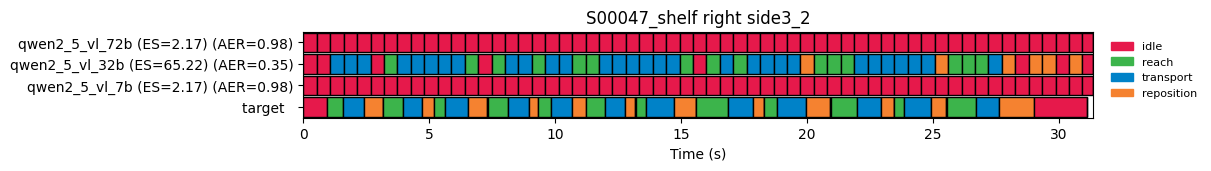

In [11]:
item = 'S00047_shelf right side3_2'
qwen_locs = [
    (qwen_model, item) for qwen_model in qwen_models
]
plot_bars_for_df(df.loc[qwen_locs])
plt.show()

In [131]:
items = df['id'].unique().tolist()

In [134]:
# item = 'S00047_shelf right side3_2'
from tqdm import tqdm

for item in tqdm(items):
    item_locs = [
        (qwen_model, item) for qwen_model in models
    ]
    fig = plot_bars_for_df(df[df['id'] == item])

    save_paths = [
        # f'./visualization/pdfs/{item.replace("/", "_")}.pdf',
        f'./visualization/pngs/{item.replace("/", "_")}.png',
    ]
    for sp in save_paths:
        p = Path(sp)
        p.parent.mkdir(parents=True, exist_ok=True)
        if p.exists():
            continue
        if p.suffix == '.pdf':
            plt.savefig(p, bbox_inches='tight')
        elif p.suffix in ('.png', '.jpg', '.jpeg'):
            plt.savefig(p, dpi=300, bbox_inches='tight')
    plt.close(fig)

100%|██████████| 50/50 [03:25<00:00,  4.11s/it]


In [129]:
df.iloc[0]['model']

'internvl3\\_78b'

### Quantitative Exploration
1) Which activities were the most difficult? What did the predictions look like for these?
2) What separates good performance vs. bad performance? E.g. in the Qwen family. Is it just a fluke? For this, use the accuracy metric. The model is "correct" if the primitive appears at least once in the window.
3) How often are the models predicting each primitive?

##### Difficult activities

In [34]:
df

,index,model,id,target,filtered_resps,edit_score,action_error_rate,mae_avg
0,0,internvl3\_78b,S00047_shelf right side3_2,idle@0.000;reach@0.917;transport@1.550;reposit...,idle@0.000;idle@0.533;transport@1.067;transpor...,52.173913,0.478261,6.0
1,1,internvl3\_78b,S00047_brushing3_1,idle@0.000;reposition@1.017;idle@1.150;reach@1...,stabilize@0.000;stabilize@0.533;stabilize@1.06...,53.061224,0.469388,4.4
2,2,internvl3\_78b,S00047_shelf right side4_1,idle@0.000;reach@0.700;transport@1.267;reposit...,idle@0.000;reposition@0.533;idle@1.067;reposit...,36.585366,0.634146,6.8
3,3,internvl3\_78b,S00044_shelf left side5_1,idle@0.000;reach@0.517;transport@2.267;reposit...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,6.122449,0.938776,9.2
4,4,internvl3\_78b,S00044_face wash5_1,idle@0.000;reach@0.767;stabilize@2.217;transpo...,idle@0.000;reposition@0.533;reposition@1.067;i...,47.058824,0.529412,4.2
...,...,...,...,...,...,...,...,...
795,795,qwen2\_5\_vl\_72b,S00026_shelf left side5_1,idle@0.000;reach@0.967;transport@2.267;reposit...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,1.886792,0.981132,10.4
796,796,qwen2\_5\_vl\_72b,S00026_feeding5_2,idle@0.000;reach@6.683;transport@7.450;stabili...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,22.641509,0.773585,8.2
797,797,qwen2\_5\_vl\_72b,S00026_feeding2_1,idle@0.000;reach@1.200;transport@2.300;stabili...,stabilize@0.000;stabilize@0.533;reach@1.067;re...,40.000000,0.600000,5.4
798,798,qwen2\_5\_vl\_72b,S00026_deodrant5_2,idle@0.000;reach@2.150;stabilize@3.067;transpo...,idle@0.000;idle@0.533;idle@1.067;idle@1.600;id...,4.761905,0.952381,4.0


In [38]:
df = df.reset_index()
performance_by_id = df.groupby('id')[['edit_score', 'action_error_rate', 'mae_avg']].mean()
performance_by_id.sort_values(by='edit_score', ascending=False, inplace=True)
ground_truths = df.groupby('id')['target'].first()
performance_by_id = performance_by_id.join(ground_truths)

In [43]:
# Don't confuse with duration
performance_by_id['last_prim_time'] = performance_by_id['target'].map(
    lambda s: _parse_segments(s)[-1]['t'] if isinstance(s, str) and s else None
)

In [45]:
# First, are edit score and action error rate correlated?
# We expect a negative correlation b/c better performance means higher edit score and lower action error rate.
# Yes, the rankings are strongly and statistically negatively correlated.
from scipy.stats import spearmanr
print(spearmanr(performance_by_id['edit_score'], performance_by_id['action_error_rate']))

SignificanceResult(statistic=-0.5832072800547781, pvalue=8.80461849687058e-06)


In [46]:
quantiles = pd.qcut(performance_by_id['edit_score'], q=5, labels=False)
performance_by_id['quantile'] = quantiles
print("Worst quantile: ", performance_by_id[performance_by_id['quantile'] == 0].index)
print("Best quantile: ", performance_by_id[performance_by_id['quantile'] == 4].index)

Worst quantile:  Index(['S00039_brushing4_1', 'S00026_RTT left side2_1',
       'S00039_shelf right side3_2', 'S00042_brushing4_1', 'S00037_glasses2_1',
       'S00047_brushing3_1', 'S00026_deodrant5_2', 'S00026_feeding5_2',
       'S00017_feeding1_1', 'S0004_deodrant5_2'],
      dtype='object', name='id')
Best quantile:  Index(['S00039_glasses5_1', 'S00039_drinking4_2', 'S0004_combing5_2',
       'S00039_combing1_2', 'S00017_glasses4_1', 'S00017_drinking5_2',
       'S00044_brushing5_2', 'S00039_drinking5_1', 'S00044_drinking2_2',
       'S00017_drinking1_1'],
      dtype='object', name='id')


In [52]:
performance_by_id = performance_by_id.reset_index()

In [7]:
# Extract the activity and patient from the ID
def extract_activity_and_patient(s: str) -> Tuple[Optional[str], Optional[str]]:
    m = re.match(r"^((?:S|C)\d+)_([A-Za-z0-9\s]*)\d_\d$", s)
    if not m:
        return None, None
    patient, activity = m.group(1), m.group(2)
    return activity, patient

In [62]:
performance_by_id[['activity', 'patient']] = performance_by_id['id'].apply(
    lambda s: pd.Series(extract_activity_and_patient(s))
)

In [65]:
performance_by_id.groupby('activity')[['edit_score', 'action_error_rate', 'mae_avg']].mean().sort_values(by='edit_score', ascending=False)

,edit_score,action_error_rate,mae_avg
activity,,,
drinking,36.570964,0.780207,3.268750
RTT right side,35.857468,0.668664,10.737500
combing,35.484221,0.769629,1.365000
glasses,35.330997,0.675740,2.508929
face wash,31.694606,0.701301,5.803125
shelf left side,31.491726,0.722628,7.579167
shelf right side,30.748125,0.890805,6.195833
brushing,30.593106,0.829144,7.766667
RTT left side,26.875000,0.731250,10.387500


In [ ]:
# The 
performance_by_id.groupby('quantile')['last_prim_time'].mean()

quantile
0    50.6118
1    40.4930
2    69.3793
3    43.0306
4    31.7463
Name: last_prim_time, dtype: float64

##### The number of times each primitive is predicted

In [126]:
action2index = {
    'idle': 0,
    'reach': 1,
    'transport': 2,
    'reposition': 3,
    'stabilize': 4,
}
prims = list(action2index.keys())
prims_cols_uncombined = [f'num_uncombined_{p}' for p in prims]
prims_cols_combined = [f'num_{p}' for p in prims]

def extract_uncombined_counts(s: str) -> pd.Series:
    segs = _parse_segments(s)
    actions = [seg['action'] for seg in segs if seg['action'] in action2index]

    num_actions = [0 for _ in range(5)]
    for a in actions:
        num_actions[action2index[a]] += 1
    return pd.Series(num_actions, index=prims_cols_uncombined)

def extract_combined_counts(s: str) -> pd.Series:
    segs = _parse_segments(s)
    actions = [seg['action'] for seg in segs if seg['action'] in action2index]
    actions = [actions[0]] + [actions[i] for i in range(1, len(actions)) if actions[i] != actions[i-1]]

    num_actions = [0 for _ in range(5)]
    for a in actions:
        num_actions[action2index[a]] += 1
    return pd.Series(num_actions, index=prims_cols_combined)


def extract_duration(s: str) -> pd.Series:
    segs = _parse_segments(s)
    actions_and_times = [(seg['action'], seg['t']) for seg in segs if seg['action'] in action2index]
    durations = [0.0 for _ in range(5)]
    for i in range(len(actions_and_times) - 1):
        a, t0 = actions_and_times[i]
        _, t1 = actions_and_times[i + 1]
        durations[action2index[a]] += (t1 - t0)
    return pd.Series(durations, index=[f'duration_{p}' for p in prims])

In [128]:
pred_uncombined_counts = df['filtered_resps'].apply(lambda s: extract_uncombined_counts(s)).sum()
pred_combined_counts = df['filtered_resps'].apply(lambda s: extract_combined_counts(s)).sum()
gt_combined_counts = df['target'].apply(lambda s: extract_combined_counts(s)).sum()
gt_durations = df['target'].apply(lambda s: extract_duration(s)).sum()

In [129]:
pred_uncombined_counts.index = [c.replace('num_uncombined_', '') for c in pred_uncombined_counts.index]
pred_combined_counts.index = [c.replace('num_', '') for c in pred_combined_counts.index]
gt_combined_counts.index = [c.replace('num_', '') for c in gt_combined_counts.index]
gt_durations.index = [c.replace('duration_', '') for c in gt_durations.index]

In [130]:
pred_uncombined_perc = (pred_uncombined_counts / pred_uncombined_counts.sum() * 100).round(1)
pred_combined_perc = (pred_combined_counts / pred_combined_counts.sum() * 100).round(1)
gt_combined_perc = (gt_combined_counts / gt_combined_counts.sum() * 100).round(1)
gt_durations_perc = (gt_durations / gt_durations.sum() * 100).round(1)

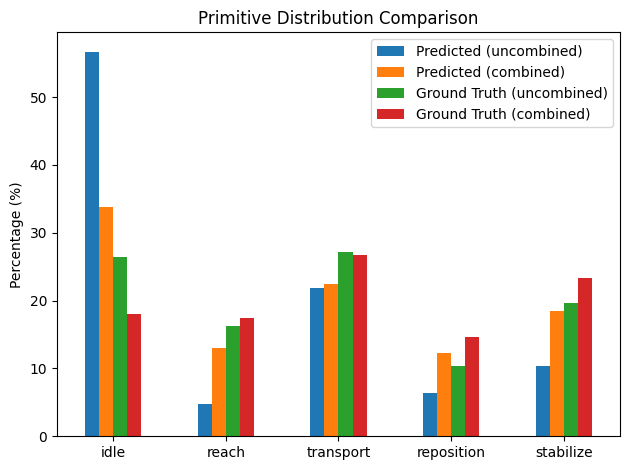

In [131]:
percs = pd.concat([pred_uncombined_perc, pred_combined_perc, gt_durations_perc, gt_combined_perc], axis=1)
percs.columns = ['Predicted (uncombined)', 'Predicted (combined)', 'Ground Truth (uncombined)', 'Ground Truth (combined)']
ax = percs.plot(kind='bar')
ax.set_ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.title('Primitive Distribution Comparison')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### How do our models perform on healthy patients?
Overall better, but the same ordering result!

In [13]:
all_results = collect_eval_results("./logs/strokerehab_primitives_7/")
all_results['date'] = all_results['file'].map(extract_timestamp_from_filename)
all_results['sampling_fps'] = all_results['sampling_fps'].astype(int)
all_results['max_frames_num'] = all_results['max_frames_num'].astype(int)
all_results.sort_values(by=['date', 'folder'], inplace=True)
all_results = all_results[(all_results['sampling_fps'] == 15) & (all_results['max_frames_num'] == 8)]
latest_results = all_results.groupby(['folder']).first()
tbl = make_results_table(latest_results)

tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_7.jsonl"))
tbl['model'] = tbl['rel_path'].apply(lambda s: s.split('/')[0])
def extract_model_and_size(s: str) -> tuple[str, float]:
    try:
        size_start_idx = -1
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    except ValueError:
        size_start_idx = -2
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    model_family = '_'.join(s.split('_')[0:size_start_idx])
    return model_family, size
tbl[['model_family', 'model_size']] = tbl['model'].apply(
    lambda s: pd.Series(extract_model_and_size(s))
)
tbl.sort_values(by=['model_family', 'model_size'], inplace=True)
tbl.drop(columns=['model_family', 'model_size'], inplace=True)
tbl['model'] = tbl['model'].apply(lambda s: s.replace('_', r'\_'))
tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_7.jsonl"))


In [19]:
_tbl = tbl[["_file", "model", "ES", "AER", "MAE", "Run time"]].copy()
_tbl = _tbl.rename(columns={"model": "Model"})
_tbl_styled = apply_best_second_styling(_tbl)
latex = results_table_to_latex(_tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
Model & ES $\uparrow$ & AER $\downarrow$ & MAE $\downarrow$ & Run time \\
\midrule
internvl3\_78b & 46.82 ± 2.50 & 0.60 ± 0.03 & 4.82 ± 0.56 & 6:50:52 \\
internvl3p5\_1b & 40.07 ± 1.66 & 0.70 ± 0.05 & 5.46 ± 0.45 & 0:37:21 \\
internvl3p5\_8b & 10.22 ± 1.60 & 0.90 ± 0.02 & 7.32 ± 0.72 & 1:09:18 \\
internvl3p5\_38b & 35.94 ± 2.58 & 0.73 ± 0.03 & 6.01 ± 0.59 & 4:40:43 \\
llava\_next\_video\_7b & \cellcolor{blue!20}\textbf{48.49 ± 3.02} & \cellcolor{blue!20}\textbf{0.55 ± 0.04} & \cellcolor{blue!20}\textbf{3.93 ± 0.44} & 0:33:46 \\
qwen2\_5\_vl\_7b & 30.86 ± 2.59 & 0.71 ± 0.03 & 6.03 ± 0.64 & 1:41:37 \\
qwen2\_5\_vl\_32b & \cellcolor{green!20}\textbf{51.84 ± 2.66} & \cellcolor{green!20}\textbf{0.53 ± 0.04} & \cellcolor{green!20}\textbf{3.72 ± 0.40} & 2:36:16 \\
qwen2\_5\_vl\_72b & 41.00 ± 2.50 & 0.62 ± 0.02 & 5.06 ± 0.54 & 4:09:22 \\
\bottomrule
\end{tabular}



In [14]:
df = explode_samples_from_jsonl_paths(tbl, path_col='samples_path', log_dir="./logs/strokerehab_primitives_7/")
df.drop(columns=['_file', '$f$', '$n$', 'Prompt', 'ES', 'AER', 'MAE', 'Run time',
       'use_video_with_segmentations', 'rel_path', 'date', '$1/d$ (rounded)',
       'samples_path'], inplace=True)
df.set_index(['model', 'id'], inplace=True)

In [22]:
len(df.loc['internvl3\_78b'])

43